In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/DCOILWTICO.csv")

df["observation_date"] = pd.to_datetime(
    df["observation_date"]
)

# 移除price缺失值
price = (
    df.loc[
        df["DCOILWTICO"].notna(),
        ["observation_date", "DCOILWTICO"]
    ]
    .set_index("observation_date")["DCOILWTICO"]
)

# Return
return_series = price.pct_change().dropna()

# Log Return
log_return_series = np.log(
    price / price.shift(1)
).dropna()

#合併return和log_return
return_df = pd.DataFrame({
    "DCOILWTICO": price,
    "return": return_series,
    "log_return": log_return_series
})

/Users/peilun/Desktop/data_project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


檢查是否定態  
H0:τ＝0 (序列有單根，資料是非定態的)  
H1:τ<0 (序列沒有單根，資料是定態的)  

經計算  
price：p-value>0.05，無法拒絕虛無假設，表示資料型態非平穩。  
return：p-value<0.05，拒絕虛無假設，表示資料型態平穩。

In [275]:
#使用ADF檢定price資料是否定態
from statsmodels.tsa.stattools import adfuller

adf_price = adfuller(price)

print("ADF Statistic:", adf_price[0])
print("p-value:", adf_price[1])

ADF Statistic: -2.5349179235319212
p-value: 0.10720788516679897


/var/folders/vw/tk3fr7d56tx7wvkmb9krpxqc0000gn/T/ipykernel_12827/2661067863.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_price = adfuller(price)


In [276]:
#使用ADF檢定return資料是否定態
adf_result = adfuller(return_series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -19.00676988730095
p-value: 0.0


/var/folders/vw/tk3fr7d56tx7wvkmb9krpxqc0000gn/T/ipykernel_12827/1921095426.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(return_series)


In [277]:
#查看資料前10筆
return_df.head(10)

,DCOILWTICO,return,log_return
observation_date,,,
1986-01-02,25.56,NaN,NaN
1986-01-03,26.00,0.017214,0.017068
1986-01-06,26.53,0.020385,0.020180
1986-01-07,25.85,-0.025631,-0.025966
1986-01-08,25.87,0.000774,0.000773
1986-01-09,26.03,0.006185,0.006166
1986-01-10,25.65,-0.014599,-0.014706
1986-01-13,25.08,-0.022222,-0.022473
1986-01-14,24.97,-0.004386,-0.004396


In [278]:
# Return 敘述性統計
return_series.describe()

count    10225.000000
mean         0.000138
std          0.042177
min         -3.019661
25%         -0.012100
50%          0.000747
75%          0.013274
max          0.530864
Name: DCOILWTICO, dtype: float64

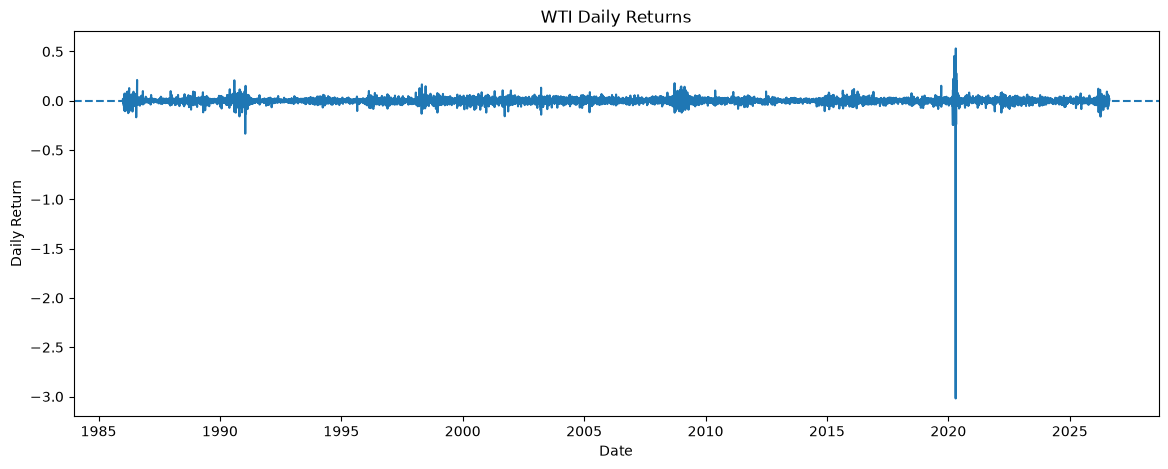

In [279]:
# Daily Return Time Series

plt.figure(figsize=(14, 5))

plt.plot(
    return_series.index,
    return_series
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("WTI Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

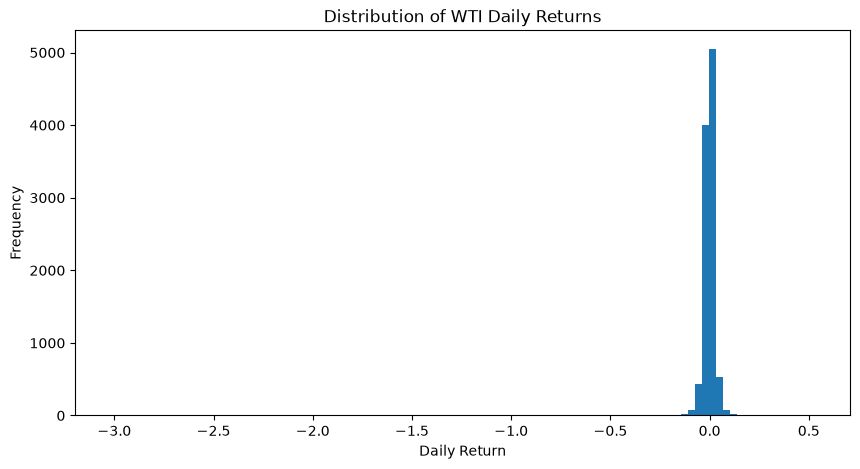

In [280]:
plt.figure(figsize=(10, 5))

plt.hist(
    return_series,
    bins=100
)

plt.title("Distribution of WTI Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

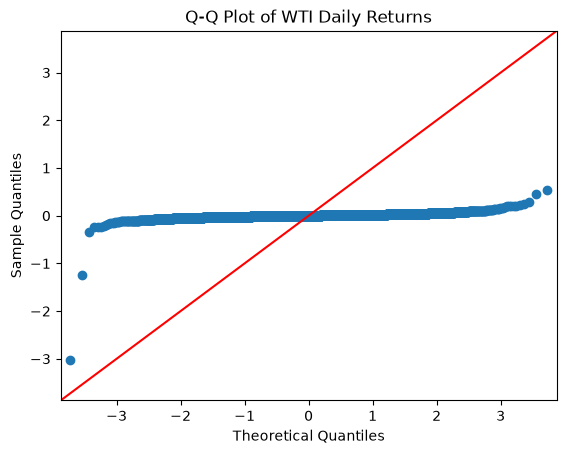

In [281]:
import statsmodels.api as sm

sm.qqplot(
    return_series,
    line="45"
)

plt.title("Q-Q Plot of WTI Daily Returns")
plt.show()

In [282]:
print("Original:")
print("Skewness:", return_series.skew())
print("Kurtosis:", return_series.kurtosis())

print("\nPositive Prices Only:")
print("Skewness:", return_positive.skew())
print("Kurtosis:", return_positive.kurtosis())

Original:
Skewness: -38.09573253945106
Kurtosis: 2648.328833972289

Positive Prices Only:
Skewness: -6.5065134550870285
Kurtosis: 330.4824759473211


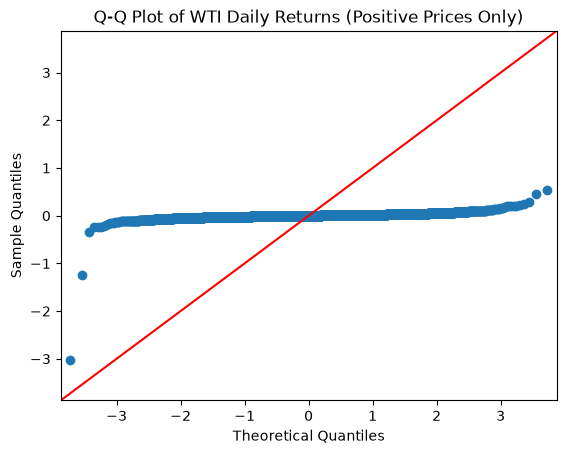

In [283]:
sm.qqplot(
    return_series,
    line="45"
)

plt.title("Q-Q Plot of WTI Daily Returns (Positive Prices Only)")
plt.show()

即使排除 negative-price event，WTI daily returns 仍明顯偏離 normality，尤其是在 tails。

波動分析

In [284]:
# 計算 30-day Rolling Volatility
rolling_volatility_30 = return_series.rolling(window=30).std()

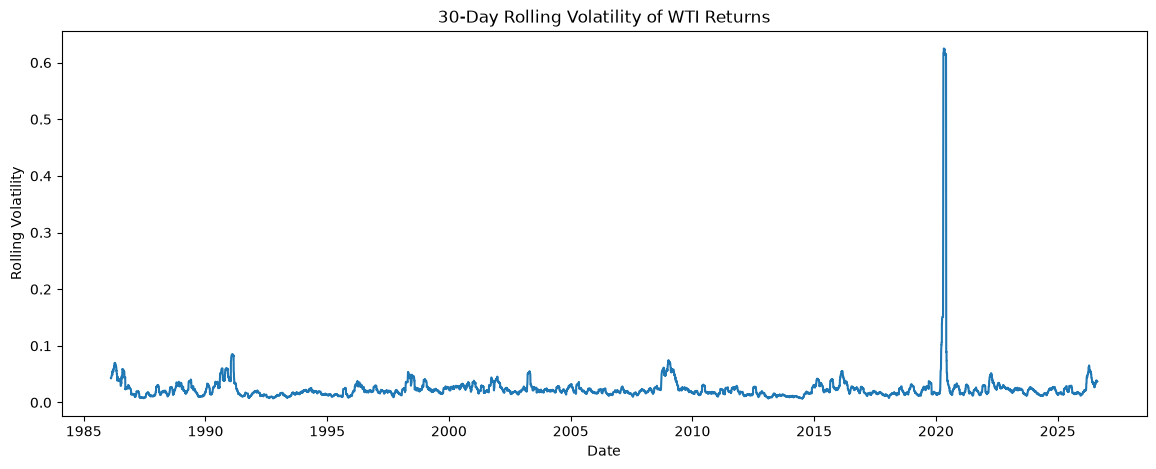

In [285]:
#畫 Rolling Volatility
plt.figure(figsize=(14, 5))

plt.plot(
    rolling_volatility_30.index,
    rolling_volatility_30
)

plt.title("30-Day Rolling Volatility of WTI Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")

plt.show()

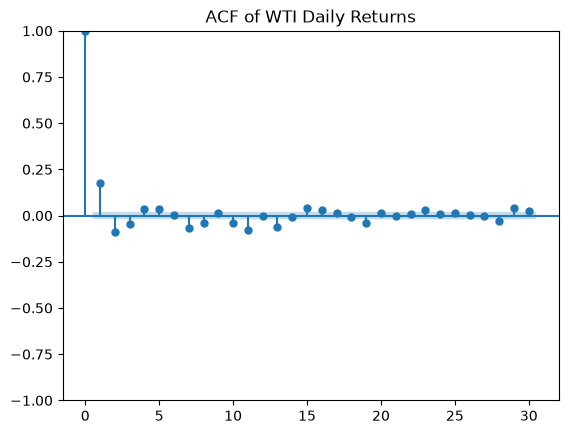

In [286]:
# actocorrelation

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    return_series,
    lags=30
)

plt.title("ACF of WTI Daily Returns")
plt.show()

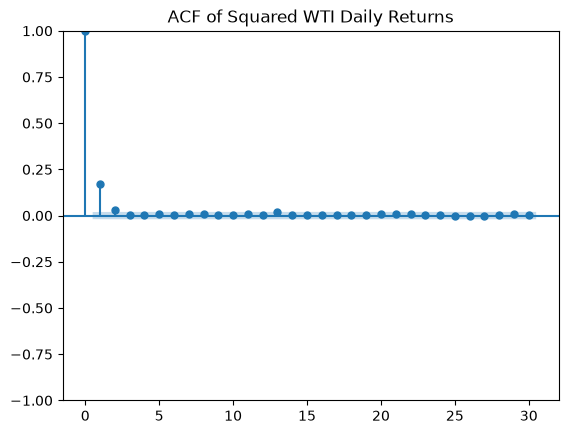

In [287]:
plot_acf(
    return_series** 2,
    lags=30
)

plt.title("ACF of Squared WTI Daily Returns")
plt.show()

價格變動方向難以預測，但波動程度可能具有持續性。


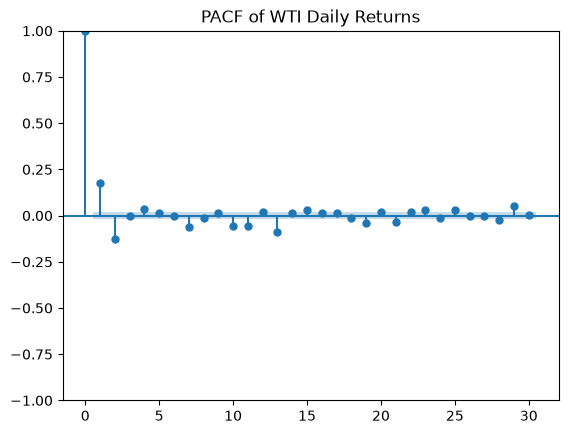

In [288]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plot_pacf(
    return_series,
    lags=30
)

plt.title("PACF of WTI Daily Returns")
plt.show()

In [289]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(
    return_series,
    lags=[10, 20],
    return_df=True
)

,lb_stat,lb_pvalue
10,525.776180,1.363511e-106
20,677.628284,1.192436e-130


In [290]:
#Squared returns 是否存在 autocorrelation？
#Ljung–Box Test on Squared Returns

acorr_ljungbox(
    return_series ** 2,
    lags=[10, 20],
    return_df=True
)



,lb_stat,lb_pvalue
10,305.305973,1.174125e-59
20,312.640972,2.102959e-54


Ljung–Box test on **returns**：  
H₀：Returns 沒有 autocorrelation  
H₁：Returns 存在 autocorrelation  
p-value<0.05 ，所以拒絕 H₀。   
結果顯示，returns 存在顯著的自我相關性，
表示報酬率與過去的報酬率之間非獨立，具有時間依賴性。

Ljung–Box test on **squared returns**：  
H₀：squared returns 沒有 autocorrelation  
H₁：squared returns 存在 autocorrelation  
p-value<0.05 ，所以拒絕 H₀。   
結果顯示，squared returns 存在顯著的自我相關性，
表示報酬率的波動程度具有時間依賴性，反應出 volatility clustering。